In [ ]:
# Save data and stuff !! yay

import serial
import matplotlib.pyplot as plt
from sensors.camera_readings import get_frame, parse_frame

In [40]:
import pandas as pd
import time

In [24]:
esp = serial.Serial("/dev/ttyUSB1", 115200)

def set_throttle(throttle):
    """
    Communicate with the ESP
    """
    esp.write(f"{throttle}\n".encode())

def get_readings():
    return parse_frame(get_frame())

In [28]:
get_readings()

{'supply_volts': 15.0,
 'supply_amps': 0.064,
 'supply_watts': 0.9,
 'scale_kg': None,
 'supply_on': True,
 'scale_on': False}

In [61]:
set_throttle(0)

In [59]:
set_throttle(800)
time.sleep(2)
set_throttle(0)

In [66]:
# Get a bunch of data?

import time

data = []

try:
    for throttle in range(700, 800, 10):
        print(f"Setting throttle to {throttle:>03}")
        set_throttle(throttle)

        # Each reading consumes roughly 30ms
        for _ in range(60):
            data.append({"throttle": throttle, **get_readings()})

        set_throttle(0)

        # Each reading consumes roughly 30ms
        for _ in range(30):
            data.append({"throttle": throttle, **get_readings()})

finally:
    set_throttle(0)

Setting throttle to 700
Setting throttle to 710
Setting throttle to 720
Setting throttle to 730
Setting throttle to 740
Setting throttle to 750
Setting throttle to 760
Setting throttle to 770
Setting throttle to 780
Setting throttle to 790


In [72]:
df

,throttle,supply_volts,supply_amps,supply_watts,scale_kg,supply_on,scale_on
0,700,15.0,NaN,NaN,2.32,None,True
1,700,15.0,NaN,NaN,NaN,None,True
2,700,15.0,NaN,NaN,2.20,None,True
3,700,15.0,NaN,NaN,2.20,None,True
4,700,15.0,NaN,NaN,1.56,None,True
...,...,...,...,...,...,...,...
895,790,15.0,0.064,6.9,0.00,True,True
896,790,15.0,NaN,NaN,0.00,None,True
897,790,15.0,0.064,6.9,0.00,True,True
898,790,15.0,0.064,6.9,0.00,True,True


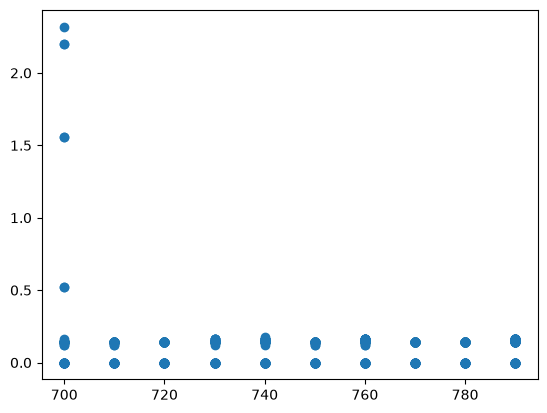

In [69]:
df = pd.DataFrame(data)

plt.scatter(df.throttle, df.scale_kg)